# Create data

Data to be used for the workflow are created in this notebook:
- base raster

- labels
- classes


## General

In [126]:
# set working directory and data folder
import os

# set working directory
data_folder = os.path.join(os.getcwd(), "data")

if not os.path.exists(data_folder):
    os.makedirs(data_folder, exist_ok=True)


## Base raster

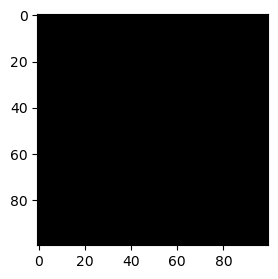

In [127]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Create the base array
base_array = np.zeros((100, 100), dtype=np.uint8)

# Create the transform
transform = rasterio.transform.from_origin(0, 0, 10, 10)

# Plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3))
ax.imshow(base_array, cmap='gray')
plt.show()


In [128]:
# Save the base raster
out_path = os.path.join(data_folder, "base_raster.tif")

with rasterio.open(out_path, "w",
                   driver="GTiff", height=base_array.shape[0], width=base_array.shape[1], count=1,
                   dtype=np.int8,
                   crs="EPSG:3857",
                   compress="lzw",
                   nodata=-99,
                   transform=transform) as dst:
    dst.write(base_array, 1)

## Labels

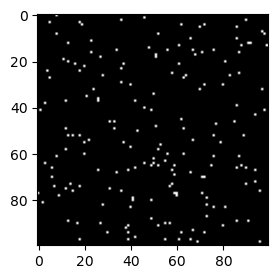

In [129]:
import numpy as np

# Create labels
noise = np.random.randint(0, 100, size=base_array.shape)
labels_array = np.where(noise >= np.percentile(noise, 99), 1, 0)

# Plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3))
ax.imshow(labels_array, cmap='gray')
plt.show()

In [130]:
# Save labels
out_path = os.path.join(data_folder, "label_raster.tif")

with rasterio.open(out_path, "w",
                   driver="GTiff", height=labels_array.shape[0], width=labels_array.shape[1], count=1,
                   dtype=np.int8,
                   crs="EPSG:3857",
                   compress="lzw",
                   nodata=-99,
                   transform=transform) as dst:
    dst.write(labels_array, 1)

## Classes raster

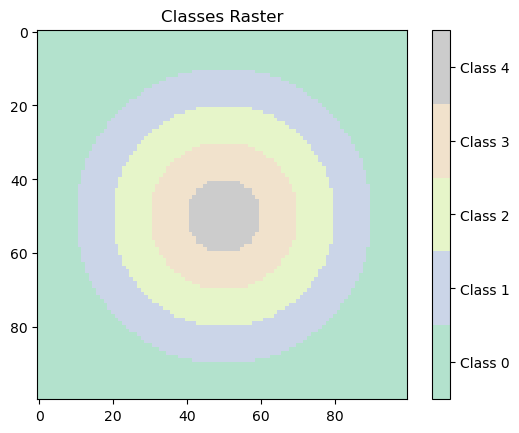

In [133]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Create classes raster
classes_array = np.zeros((100, 100), dtype=np.int8)

# Define the center of the array
center_x, center_y = 50, 50

# Define the radius for each class
radii = [0, 10, 20, 30, 40]

# Assign values based on distance from the center
for i in range(classes_array.shape[0]):
    for j in range(classes_array.shape[1]):
        distance = np.sqrt((i - center_x) ** 2 + (j - center_y) ** 2)
        for class_value, radius in enumerate(reversed(radii), start=0):
            if (distance >=radius):
                classes_array[i, j] = class_value
                break

# Plot the classes
cmap = plt.get_cmap("Pastel2", 5)  # 5 discrete colors for classes 1-4 and background
values = np.unique(classes_array)
ticks = np.unique(classes_array)

plt.imshow(classes_array, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(values=values, ticks=ticks)

class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
cbar.ax.set_yticklabels(class_labels)

plt.title("Classes Raster")
plt.show()


In [134]:
# Save the base raster
out_path = os.path.join(data_folder, "classes_raster.tif")

with rasterio.open(out_path, "w",
                   driver="GTiff", height=base_array.shape[0], width=base_array.shape[1], count=1,
                   dtype=np.int8,
                   crs="EPSG:3857",
                   compress="lzw",
                   nodata=-99,
                   transform=transform) as dst:
    dst.write(classes_array, 1)